# Regression Track — UrbanGlide Energy Consumption Prediction

**Goal:** predict `energy_consumed_wh` per micro-mobility trip using the 10 algorithms required by the capstone guidelines, on a single leakage-safe 80:20 split.

**Owner:** Person A (EDA + preprocessing + linear family) and Person C (ensembles + tuning + CV + diagnostics) — see the commit history for exactly who added which section.

---

### Section 0 — Imports

Standard data/ML stack: pandas and numpy for data handling, matplotlib/seaborn for plotting, and the specific scikit-learn estimators, preprocessing tools and metrics this track needs.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 95
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

print("Libraries loaded.")


Libraries loaded.


### Step 1.1 — Dataset loading, schema & audit

Load the raw CSV and report shape, dtypes, missing-value counts and target summary statistics before touching anything — this is what decides the imputation strategy and flags skew before a single plot is drawn.

In [2]:
reg_file = "../data/urbanglide_regression_energy.csv"
df = pd.read_csv(reg_file)

print("=" * 65)
print("  REGRESSION DATASET AUDIT")
print("=" * 65)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
print("Column dtypes:")
for col, dt in df.dtypes.items():
    print(f"  {col:<30} {dt}")

mv = df.isnull().sum()
miss = pd.DataFrame({'Missing Count': mv, 'Missing %': (mv/len(df)*100).round(2)})[mv > 0]
print("\nMissing value profile:")
print(miss.to_string() if len(miss) else "  None")

print("\nTarget ('energy_consumed_wh') summary:")
print(df['energy_consumed_wh'].describe().round(2).to_string())


  REGRESSION DATASET AUDIT
Shape: 12,035 rows x 15 columns

Column dtypes:
  trip_id                        int64
  vehicle_type                   str
  distance_km                    float64
  duration_min                   float64
  avg_speed_kmph                 float64
  terrain_elevation_gain_m       float64
  temperature_c                  float64
  humidity_percent               float64
  battery_start_percent          float64
  rider_weight_kg                float64
  traffic_congestion_index       float64
  time_of_day                    str
  weather_condition              str
  num_stops                      int64
  energy_consumed_wh             float64

Missing value profile:
                          Missing Count  Missing %
terrain_elevation_gain_m             80       0.66
humidity_percent                     80       0.66
weather_condition                    80       0.66

Target ('energy_consumed_wh') summary:
count    12035.00
mean       146.30
std         55.75
min 

#### Output analysis

- **Shape:** 12,035 rows x 15 columns.
- **Missing values:** isolated to `terrain_elevation_gain_m`, `humidity_percent`, `weather_condition` — each around 0.66% of rows. All three missing counts are within a couple of rows of each other, which points to the missingness being random (MCAR) rather than systematic, so simple median/mode imputation is defensible.
- **Target skew:** mean (146.30) is noticeably above the median (138.18), which already signals a right-skewed distribution before any plot is drawn — a handful of long trips pull the mean up.

### Step 1.2 — Target distribution & outlier boundary

Histogram + KDE with mean/median markers, a boxplot, and the 3xIQR *extreme*-outlier boundary (deliberately more conservative than the standard 1.5xIQR fence, so only genuine anomalies get flagged rather than the legitimate tail of long trips).

3xIQR outlier boundary: > 374.23 Wh
Extreme outliers: 25 (0.21% of rows)


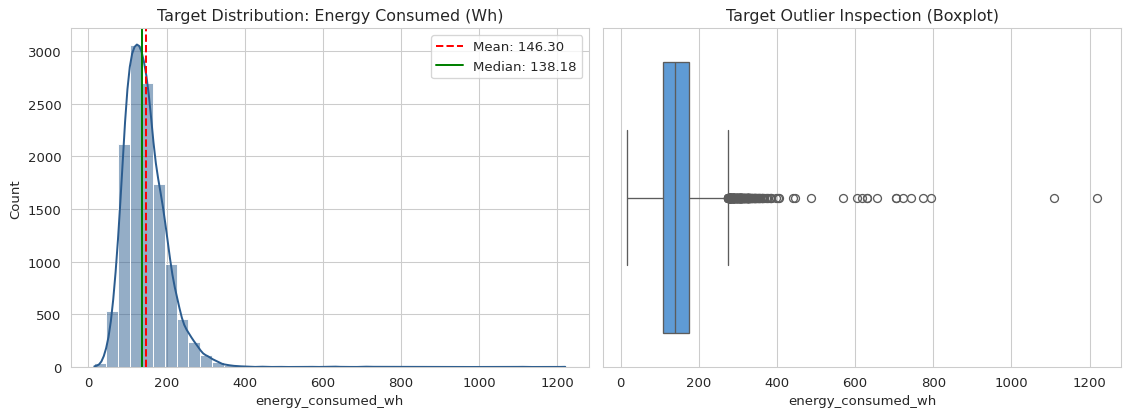

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df['energy_consumed_wh'], kde=True, ax=axes[0], color='#2b5c8f', bins=40)
axes[0].axvline(df['energy_consumed_wh'].mean(), color='red', linestyle='--', label=f"Mean: {df['energy_consumed_wh'].mean():.2f}")
axes[0].axvline(df['energy_consumed_wh'].median(), color='green', linestyle='-', label=f"Median: {df['energy_consumed_wh'].median():.2f}")
axes[0].set_title("Target Distribution: Energy Consumed (Wh)")
axes[0].legend()

sns.boxplot(x=df['energy_consumed_wh'], ax=axes[1], color='#4c9be8')
axes[1].set_title("Target Outlier Inspection (Boxplot)")
plt.tight_layout()
plt.show()

q1 = df['energy_consumed_wh'].quantile(0.25)
q3 = df['energy_consumed_wh'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 3 * iqr
n_outliers = (df['energy_consumed_wh'] > upper_bound).sum()
print(f"3xIQR outlier boundary: > {upper_bound:.2f} Wh")
print(f"Extreme outliers: {n_outliers} ({n_outliers/len(df)*100:.2f}% of rows)")


#### Output analysis

- 75% of trips use under 175 Wh, but the max is 1220 Wh — a long but thin tail.
- The 3xIQR boundary sits at **374.23 Wh**, flagging only **25 rows (0.21%)** as extreme outliers. This is intentionally conservative — a 1.5xIQR fence would flag far more rows and start cutting into legitimate long trips, not just anomalies.
- These rows are **not dropped yet**. Trimming happens later, inside the leakage-safe preprocessing step, using bounds computed from the training split only — not from this full-dataset number.